In [1]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [36]:
from GridMaze.analysis.neGLM import load_model_sets as lms
from GridMaze.analysis.neGLM import model_comparisons as mc

reload(lms)
reload(mc)

<module 'GridMaze.analysis.neGLM.model_comparisons' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/neGLM/model_comparisons.py'>

baseline vs embedding:
                      feature_group model_type     t_stat     p_val  \
0                   place_direction  baseline2   7.985724  0.000497   
1                   place_direction   baseline  11.806885  0.000077   
2  place_direction_distance_to_goal  baseline2   8.241120  0.000429   
3  place_direction_distance_to_goal   baseline  11.308994  0.000095   
4                             place   baseline   6.054119  0.001773   

   p_val_corr  
0    0.000621  
1    0.000236  
2    0.000621  
3    0.000236  
4    0.001773  


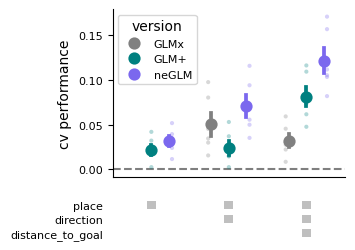

In [46]:
reload(mc)
nbe_validation = lms.load_model_set_cv_scores(
    model_set="performance_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
f, axes = plt.subplots(2, 1, sharex=True, figsize=(3, 3), gridspec_kw={"height_ratios": [4, 1]})
mc.plot_performance_validation(nbe_validation, plot_single_subjects=True, axes=axes)

place_direction_factorised vs place_direction_nonlinear
t_stat: -5.306830646355353, p_val: 0.003174222287973421
place_direction_distance_to_goal_factorised vs place_direction_distance_to_goal_nonlinear
t_stat: 1.4179475992257404, p_val: 0.2154064267641584


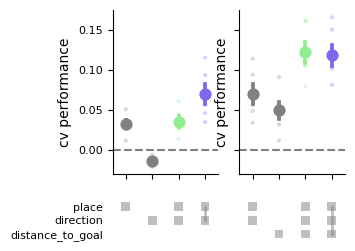

In [54]:
reload(mc)
interaction_validation_results = lms.load_model_set_cv_scores(
    "interaction_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

f, axes = plt.subplots(
    2,
    2,
    figsize=(3, 3),
    sharey="row",
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.25},
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=["place", "direction", "place_direction_factorised", "place_direction_nonlinear"],
    plot_single_subjects=True,
    axes=axes[:, 0],
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=[
        "place_direction_conjunction",
        "distance_to_goal",
        "place_direction_distance_to_goal_factorised",
        "place_direction_distance_to_goal_nonlinear",
    ],
    plot_single_subjects=True,
    axes=axes[:, 1],
)

In [55]:
from GridMaze.analysis.neGLM import variance_explained as ve

reload(ve)

<module 'GridMaze.analysis.neGLM.variance_explained' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/neGLM/variance_explained.py'>

In [81]:
reload(ve)
late_sessions = False
model_set_name = "variance_explained" if late_sessions else "variance_explained_all_sessions"
variance_explained_results = lms.load_model_set_cv_scores(
    model_set_name, maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
reduced_models = [
    "remove_distance_to_goal",
    "remove_place_direction",
]
cpd_df = ve.get_cpd_df(variance_explained_results, reduced_models=reduced_models, full_model_sig=True, alpha=0.05)
feature_tuned_df = ve.get_feature_tuned_df(variance_explained_results, reduced_models=reduced_models, alpha=0.01)

models = [f.split("_", 1)[-1] for f in reduced_models]

            feature    t_stat     p_val  p_val_corr
0  distance_to_goal  6.038299  0.000897    0.000897
1   place_direction  8.412927  0.000195    0.000389


(-0.5, 16.0)

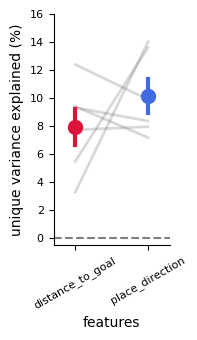

In [79]:
reload(ve)
f, ax = plt.subplots(figsize=(1.5, 3))
ve.plot_variance_explained(
    cpd_df,
    features=models,
    plot_single_subject=True,
    print_stats=True,
    ax=ax,
)
ax.set_ylim(-0.5, 16)

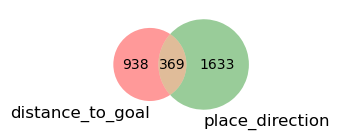

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ve.plot_summary_venn_diagram(
    feature_tuned_df,
    models=models,
    ax=ax,
)